# Customer segmentation with clustering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage



In [3]:
data = pd.read_csv('https://github.com/FourthRevGitHub/CAM_DS_Public-Data-Sets/raw/main/Course%201/Week%206/CUSTOMERS_CLEAN.zip')

# Initial data exploration and assessment

Perform EDA

In [4]:
data.shape

(951669, 20)

In [5]:
data.sample(5)


,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
775707,1,Barnet,Europe,EN4 0DY,Hertfordshire,20MAR2016,20MAR2016,$167.20,$143.20,.,Retail Sale,United Kingdom,27MAY1993,Orion Club Gold members,Orion Club Gold members high activity,1241757697,$24.00,0,99,63234
765926,1,Tucson,North America,85706,Arizona,28FEB2016,28FEB2016,$29.40,$27.10,.,Retail Sale,United States,13FEB1953,Orion Club members,Orion Club members medium activity,1241569284,$2.30,0,99,38733
616117,1,Unterschleißheim,Europe,85716,Bayern,09MAY2015,09MAY2015,$114.20,$114.40,.,Retail Sale,Germany,07NOV1963,Orion Club members,Orion Club members high activity,1239147893,($0.20),0,0,40253
752014,1,'S-Hertogenbosch,Europe,5232 CE,NaN,30JAN2016,30JAN2016,$35.20,$32.40,.,Retail Sale,Netherlands,13DEC1983,Orion Club Gold members,Orion Club Gold members high activity,1241305121,$2.80,0,99,76508
435952,2,London,Europe,W12 7SL,City of London,17JUN2014,20JUN2014,$119.00,$59.70,.,Internet Sale,United Kingdom,18APR1993,Orion Club Gold members,Orion Club Gold members medium activity,1236133347,($0.40),3,0,52452


In [6]:
data.describe()

,Quantity,Order ID,Days to Delivery,Loyalty Num,Customer ID
count,951669.000000,9.516690e+05,951669.000000,951669.000000,951669.000000
mean,1.678438,1.236943e+09,1.056107,66.534079,45440.602683
std,0.899914,4.273202e+06,2.065725,46.476795,27214.145206
min,1.000000,1.230000e+09,0.000000,0.000000,1.000000
25%,1.000000,1.233081e+09,0.000000,0.000000,22139.000000
50%,1.000000,1.236755e+09,0.000000,99.000000,44140.000000
75%,2.000000,1.240689e+09,1.000000,99.000000,70411.000000
max,10.000000,1.244338e+09,32.000000,99.000000,94254.000000


In [7]:
#Id any missing values
data.isna().sum()

,0
Quantity,0
City,135
Continent,0
Postal_Code,3716
State_Province,117192
Order_Date,0
Delivery_Date,0
Total Revenue,0
Unit Cost,0
Discount,0


In [8]:
#Id duplicate rows
duplicate_rows = data.loc[data.duplicated(keep=False)]
print(len(duplicate_rows))
print(duplicate_rows.head(3))

42
       Quantity  City Continent Postal_Code       State_Province Order_Date  \
25808         1  Köln    Europe       51105  Nordrhein-Westfalen  08MAR2012   
25809         1  Köln    Europe       51105  Nordrhein-Westfalen  08MAR2012   
59722         2  Roma    Europe       00167                Lazio  24MAY2012   

      Delivery_Date Total Revenue Unit Cost Discount OrderTypeLabel  \
25808     08MAR2012       $59.70    $59.90         .    Retail Sale   
25809     08MAR2012       $59.70    $59.90         .    Retail Sale   
59722     24MAY2012       $26.40    $11.90         .    Retail Sale   

      CustomerCountryLabel Customer_BirthDate           Customer_Group  \
25808              Germany          15MAR1958       Orion Club members   
25809              Germany          15MAR1958       Orion Club members   
59722                Italy          18SEP1993  Orion Club Gold members   

                               Customer_Type    Order ID   Profit  \
25808    Orion  Club members 

In [9]:
#Remove duplicate rows
data.drop_duplicates(inplace=True)

In [10]:
#Id any duplicate Order IDs
duplicate_order_ids = data.loc[data.duplicated(subset=['Order ID'], keep=False)]
print(len(duplicate_order_ids))
print(duplicate_order_ids.head(5))

386888
    Quantity               City Continent Postal_Code     State_Province  \
1          2            Berowra   Oceania        2081    New South Wales   
2          2            Berowra   Oceania        2081    New South Wales   
8          1  Frankfurt am Main    Europe       60325             Hessen   
9          1  Frankfurt am Main    Europe       60325             Hessen   
10         2    Bad Mergentheim    Europe       97980  Baden-Württemberg   

   Order_Date Delivery_Date Total Revenue Unit Cost Discount OrderTypeLabel  \
1   01JAN2012     04JAN2012      $113.40    $56.90         .  Internet Sale   
2   01JAN2012     04JAN2012       $41.00    $18.50         .  Internet Sale   
8   01JAN2012     04JAN2012      $155.80   $129.90         .  Internet Sale   
9   01JAN2012     04JAN2012       $39.00    $30.00         .  Internet Sale   
10  01JAN2012     06JAN2012      $285.80   $143.10         .  Internet Sale   

   CustomerCountryLabel Customer_BirthDate              Custo

In [11]:
#Remove all duplicate order IDs
data.drop_duplicates(subset=['Order ID'], inplace=True, keep='first')

In [12]:
print(data.shape[0])

747953


# Create new features

In [13]:
#Calculate time since order
data['Recency'] = (pd.to_datetime('today') - pd.to_datetime(data['Delivery_Date'])).dt.days

#Calculate customer age
data['DOB'] = pd.to_datetime(data['Customer_BirthDate'], format='%d%b%Y')
today = pd.Timestamp('now')
data['Age'] = (today - data['DOB']).dt.days // 365

# Clean Revenue and Cost columns: remove '$' and ',' then convert to float
data['Total Revenue'] = data['Total Revenue'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
data['Unit Cost'] = data['Unit Cost'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

#Apply aggregation
data_aggr = data.groupby('Customer ID').agg({
    'Order ID': 'count',
    'Recency': 'min',
    'Total Revenue': 'sum',
    'Unit Cost': 'mean',
    'Age': 'min'
}).reset_index()

#Rename the columns
data_aggr = data_aggr.rename(columns={'Order ID': 'Frequency',
                                  'Total Revenue': 'CLV',
                                  'Unit Cost': 'Average_Unit_Cost',
                                  })

#Keep only needed columns
cols_to_keep = ['Customer ID','Frequency', 'Recency', 'CLV', 'Average_Unit_Cost', 'Age']

data_clean = data_aggr.drop(columns=data_aggr.columns.difference(cols_to_keep))
data_clean = data_clean.reset_index(drop=True)


/tmp/ipykernel_227/2899770400.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Recency'] = (pd.to_datetime('today') - pd.to_datetime(data['Delivery_Date'])).dt.days


In [14]:
data_clean.sample(5)

,Customer ID,Frequency,Recency,CLV,Average_Unit_Cost,Age
17453,22659,11,3454,1477.9,72.909091,62
67858,93666,1,3859,301.8,103.800000,82
40840,52754,7,3638,926.5,71.200000,38
57523,79152,2,3803,124.9,46.050000,52
33542,43341,5,3459,680.7,36.900000,62


In [15]:
data_clean.shape[0]

68300

EDA on the newly created features

In [16]:
#Evidence if the DOB values have been creates synthetically \
#as the histogram plot of ages is spikey
data['DOB'].dt.year.value_counts().sort_index(ascending=True)

,count
DOB,
1943,30360
1948,31477
1952,69
1953,55206
1958,61248
1963,57396
1968,64071
1972,82
1973,64936


In [17]:
features = ['Frequency', 'Recency', 'CLV', 'Average_Unit_Cost', 'Age']

data_clean[features].describe()

,Frequency,Recency,CLV,Average_Unit_Cost,Age
count,68300.000000,68300.000000,68300.000000,68300.000000,68300.000000
mean,10.950996,3730.399971,1500.821421,77.770998,52.356149
std,8.771057,414.289931,1319.072192,39.909294,17.487062
min,1.000000,3344.000000,0.630000,0.500000,28.000000
25%,5.000000,3408.000000,539.987500,55.545726,37.000000
50%,9.000000,3552.000000,1154.900000,71.850000,52.000000
75%,15.000000,3902.000000,2085.025000,91.550962,67.000000
max,101.000000,5188.000000,15553.260000,1463.500000,83.000000


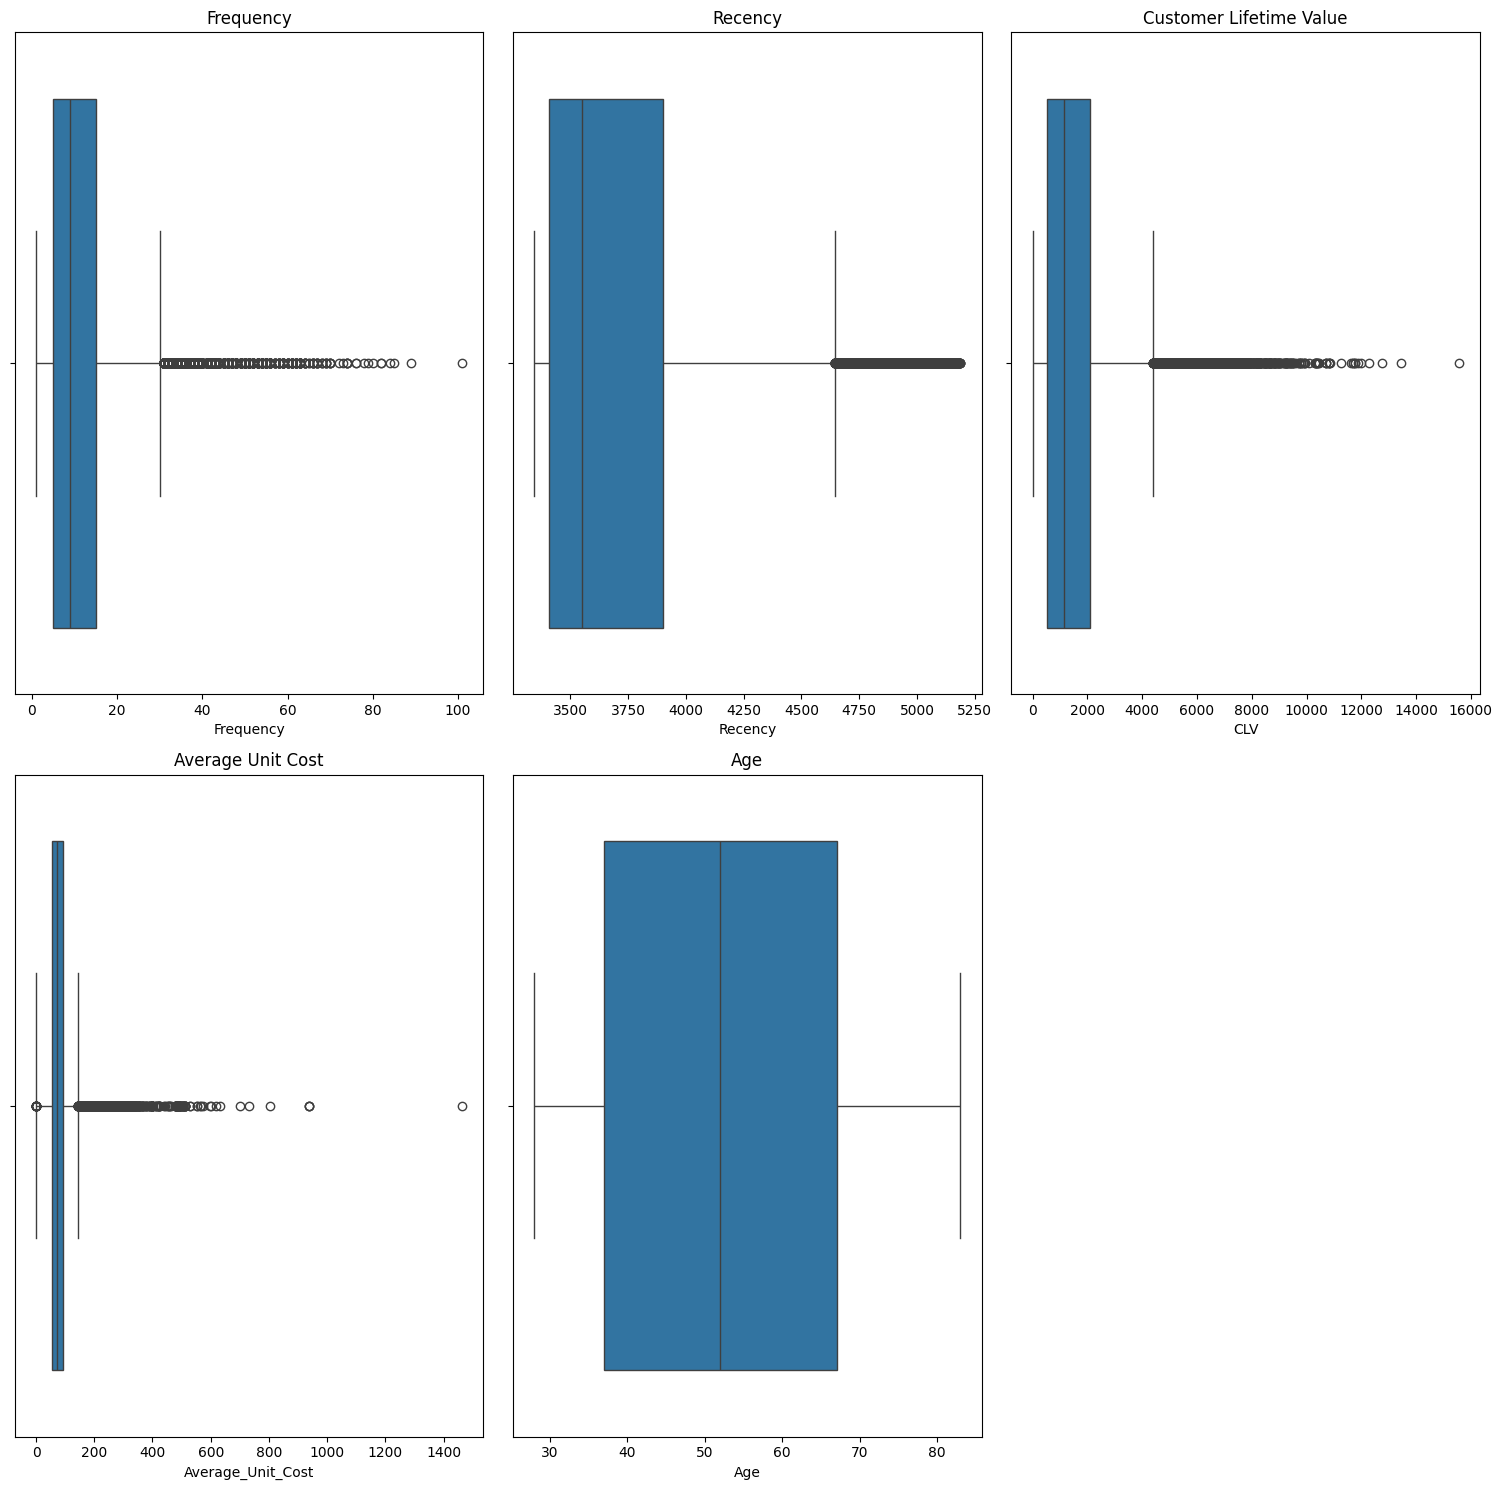

In [18]:
#Identify any outliers

fig, axes = plt.subplots(2, 3, figsize=(15, 15))

sns.boxplot(x=data_clean['Frequency'], ax=axes[0, 0])
axes[0, 0].set_title('Frequency')

sns.boxplot(x=data_clean['Recency'], ax=axes[0, 1])
axes[0, 1].set_title('Recency')

sns.boxplot(x=data_clean['CLV'], ax=axes[0, 2])
axes[0, 2].set_title('Customer Lifetime Value')

sns.boxplot(x=data_clean['Average_Unit_Cost'], ax=axes[1, 0])
axes[1, 0].set_title('Average Unit Cost')

sns.boxplot(x=data_clean['Age'], ax=axes[1, 1])
axes[1, 1].set_title('Age')

axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

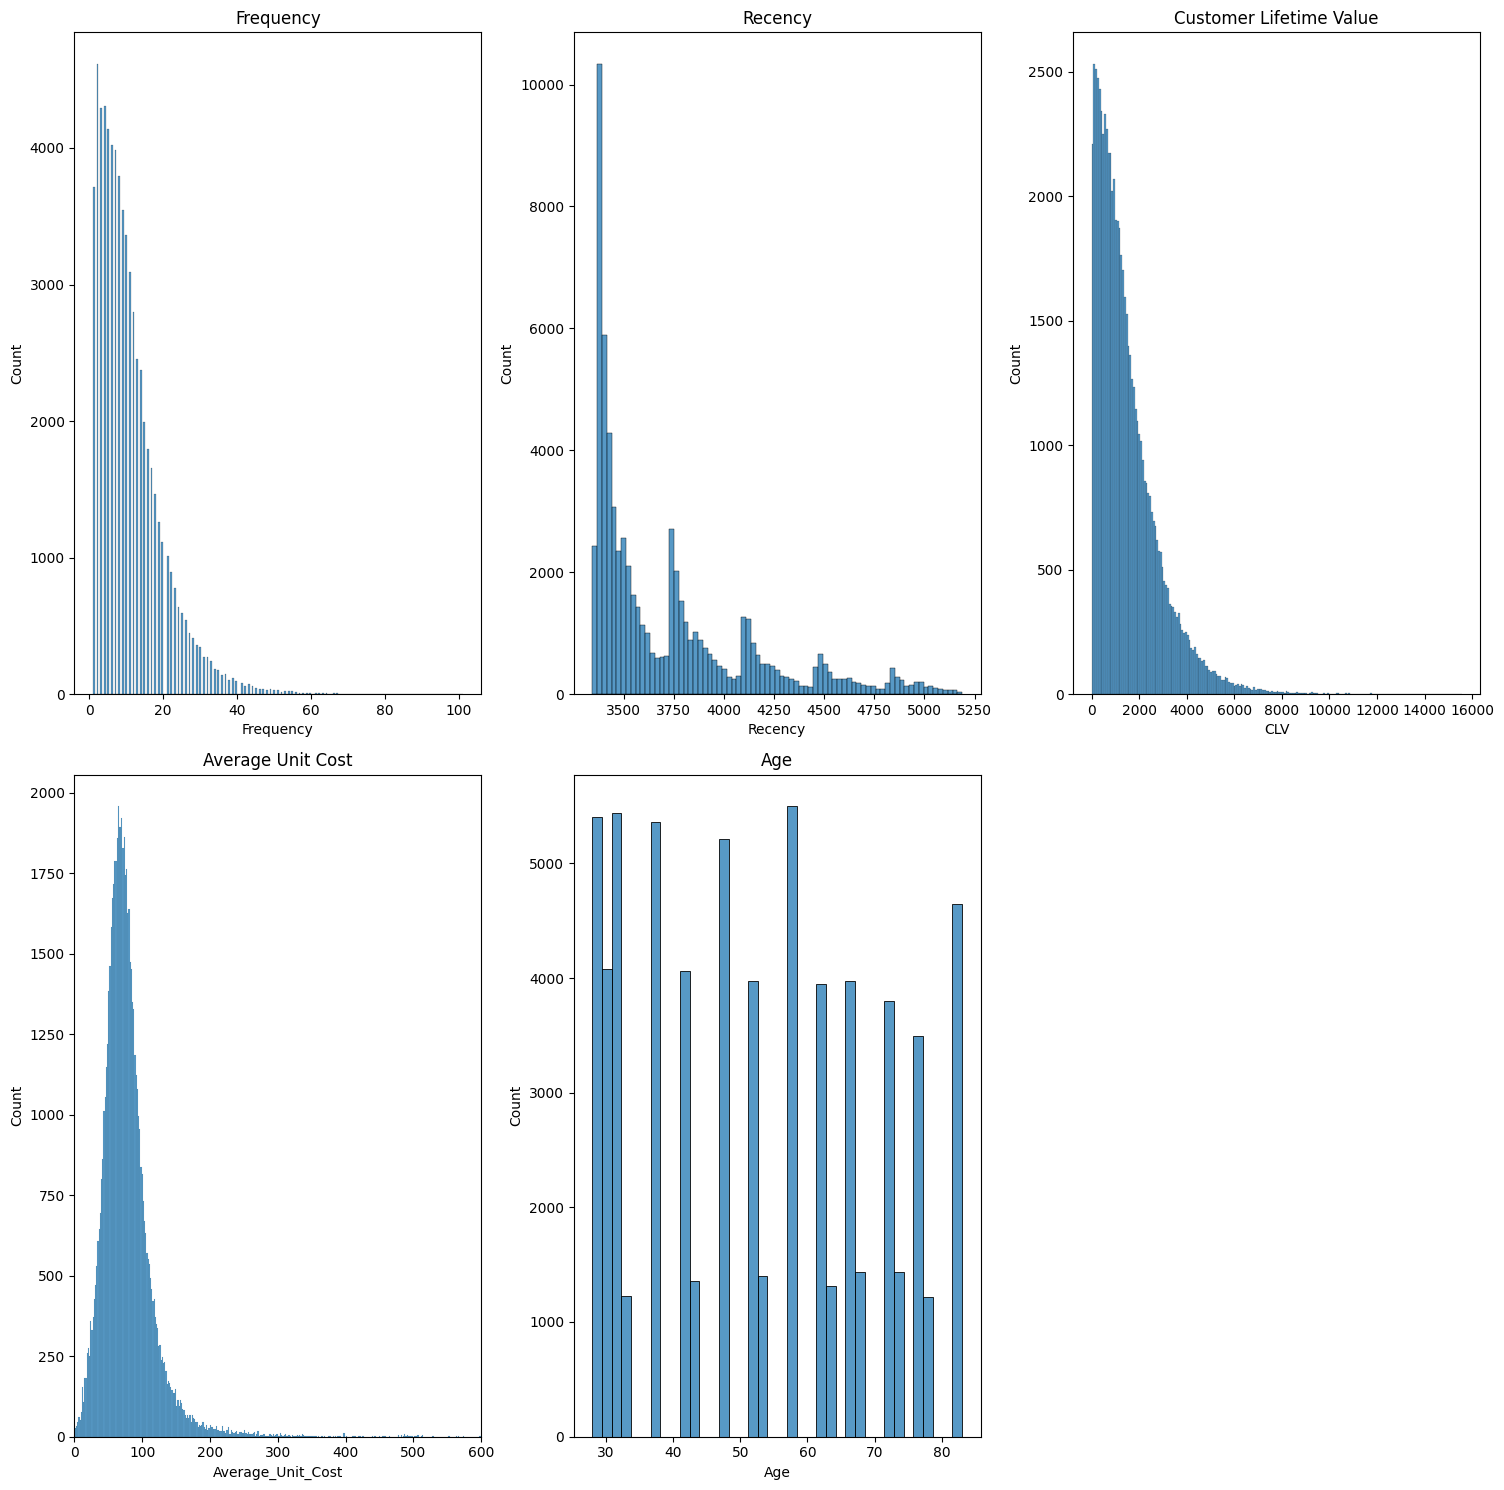

In [19]:
#Plot distributions of features

fig, axes = plt.subplots(2, 3, figsize=(15, 15))

sns.histplot(x=data_clean['Frequency'], ax=axes[0, 0])
axes[0, 0].set_title('Frequency')

sns.histplot(x=data_clean['Recency'], ax=axes[0, 1])
axes[0, 1].set_title('Recency')

sns.histplot(x=data_clean['CLV'], ax=axes[0, 2])
axes[0, 2].set_title('Customer Lifetime Value')

sns.histplot(x=data_clean['Average_Unit_Cost'], ax=axes[1, 0])
axes[1, 0].set_title('Average Unit Cost')
axes[1, 0].set_xlim(0, 600)

sns.histplot(x=data_clean['Age'], ax=axes[1, 1])
axes[1, 1].set_title('Age')

axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

# Clustering with ML models

# Use the elbow method to determine optimal number of clusters

In [20]:
#Est. the preprocessor
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), features)])

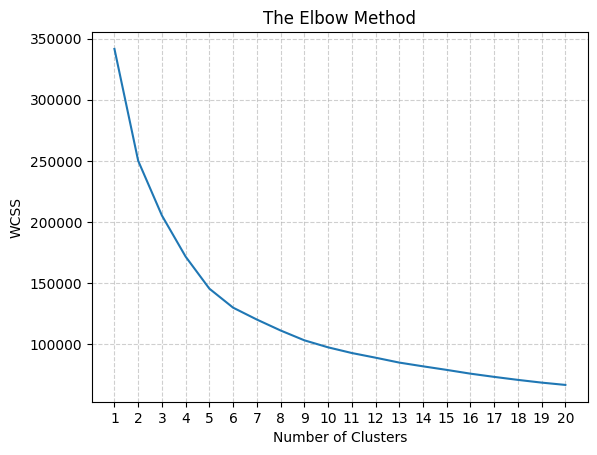

In [21]:
#Calculate inertia for different cluster numbers

wcss=[]
for i in range(1,21):
    clusterer=KMeans(n_clusters=i, init='k-means++',random_state=42, n_init = 10)

    #Est. pipline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('clusterer', clusterer)])

    #Fit the pipeline to the data
    pipeline.fit(data_clean[features])

    #Store inertia
    wcss.append(clusterer.inertia_)

plt.plot(range(1,21),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Reflections on the optimal $k$ in light of the results from the Elbow Method**

There is a sharp bend ak $k=2$ - around $k=5$ or $k=6$ the reductions in Within Cluster Sum of Squares (WCSS) level off. Based on these results, this suggests that the optimal value of $k$ is 2 or 5.



# Use the Silhouette Method to determine optimum number of clusters

In [ ]:
n_clusters_range = np.arange(start=2, stop=7, step=1)

For n_clusters = 2, the average silhouette_score is: 0.2629960832818254
For n_clusters = 2 clusters, the lowest sample silhouette value is -0.0825466408765243
For n_clusters = 3, the average silhouette_score is: 0.25206854671462253
For n_clusters = 3 clusters, the lowest sample silhouette value is -0.11466488000470532
For n_clusters = 4, the average silhouette_score is: 0.2533877040864659
For n_clusters = 4 clusters, the lowest sample silhouette value is -0.15298461868159566
For n_clusters = 5, the average silhouette_score is: 0.2669763658189616
For n_clusters = 5 clusters, the lowest sample silhouette value is -0.18998481151517074
For n_clusters = 6, the average silhouette_score is: 0.2519082987580848
For n_clusters = 6 clusters, the lowest sample silhouette value is -0.19644255562147608


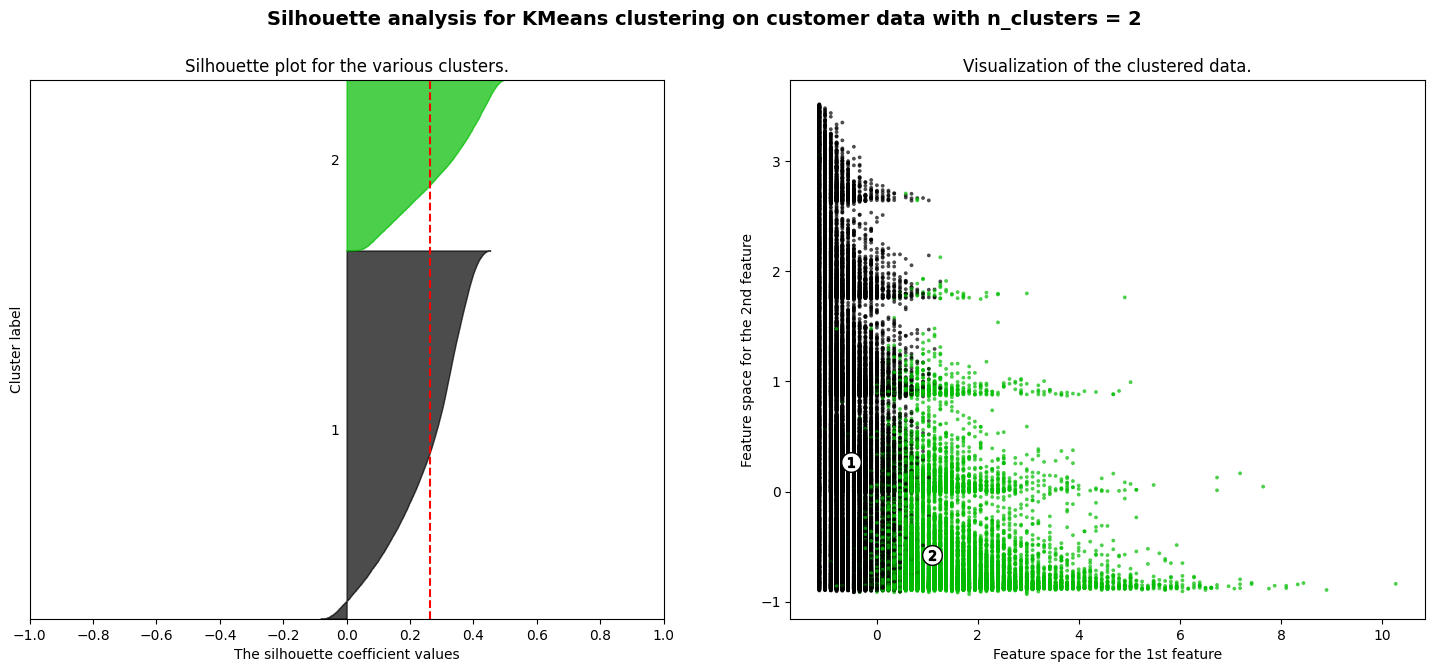

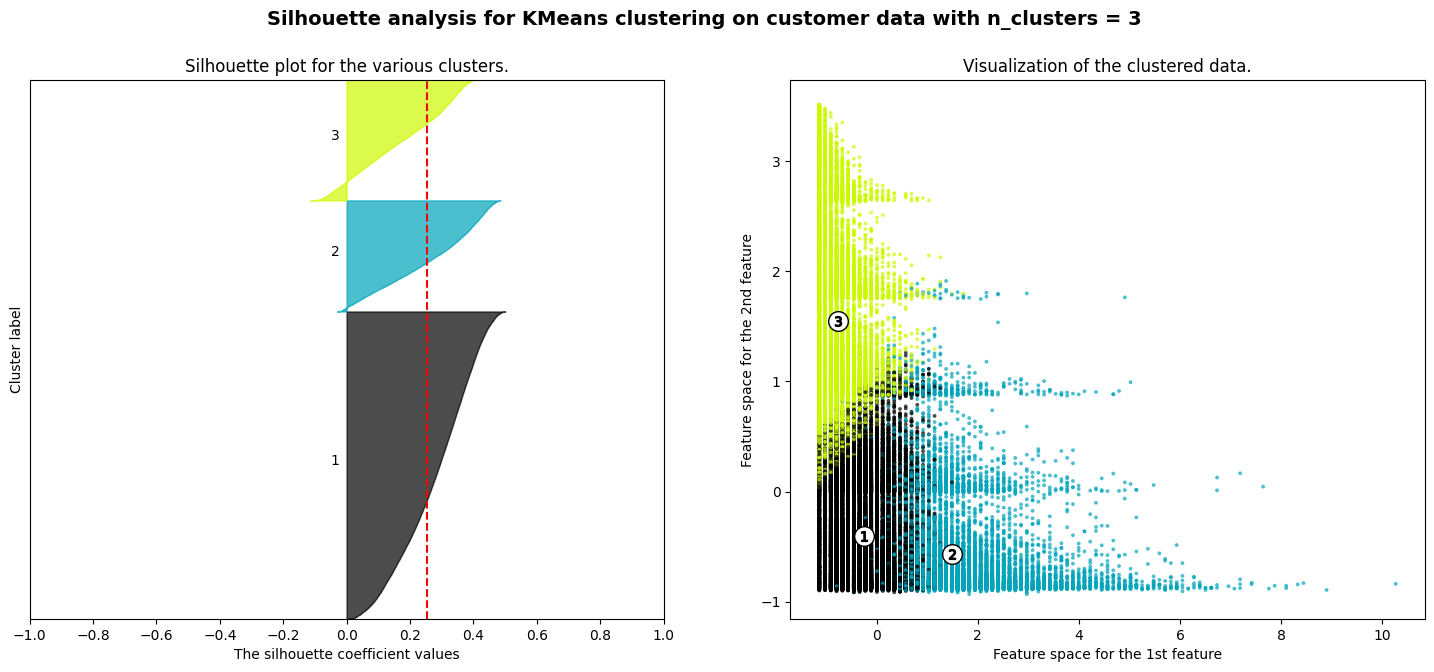

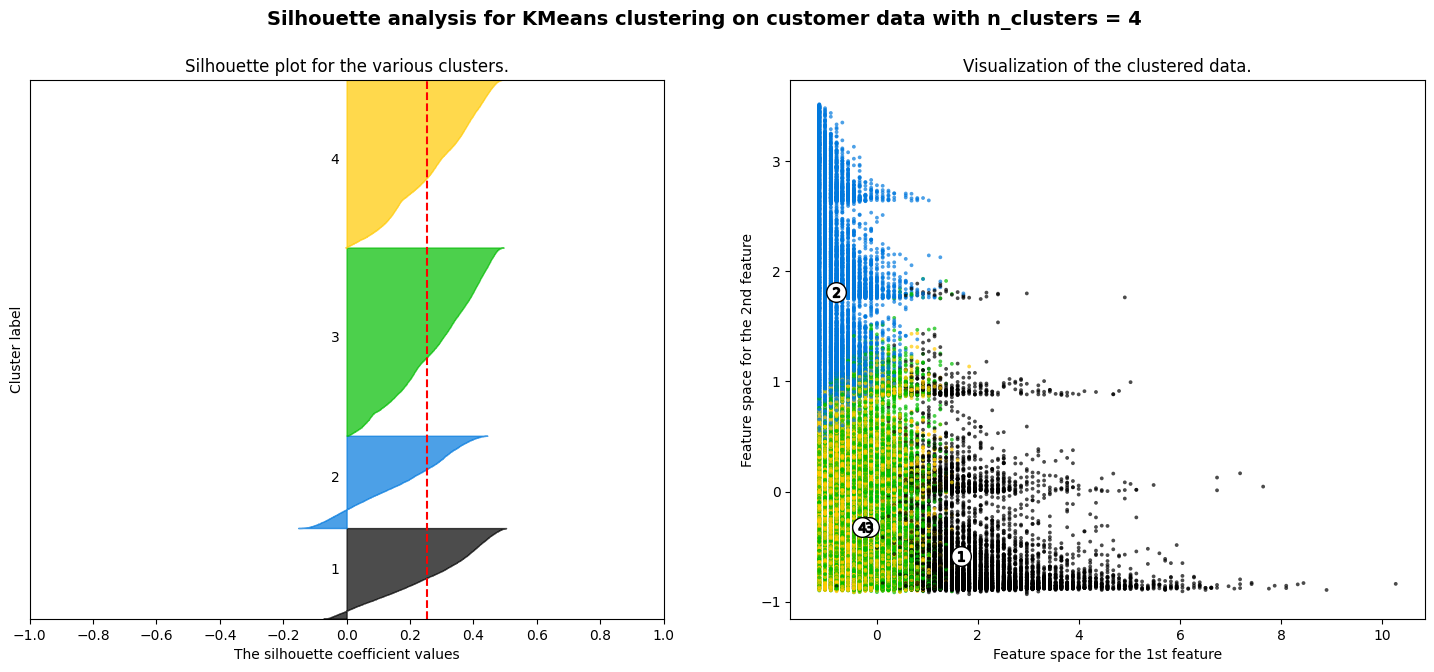

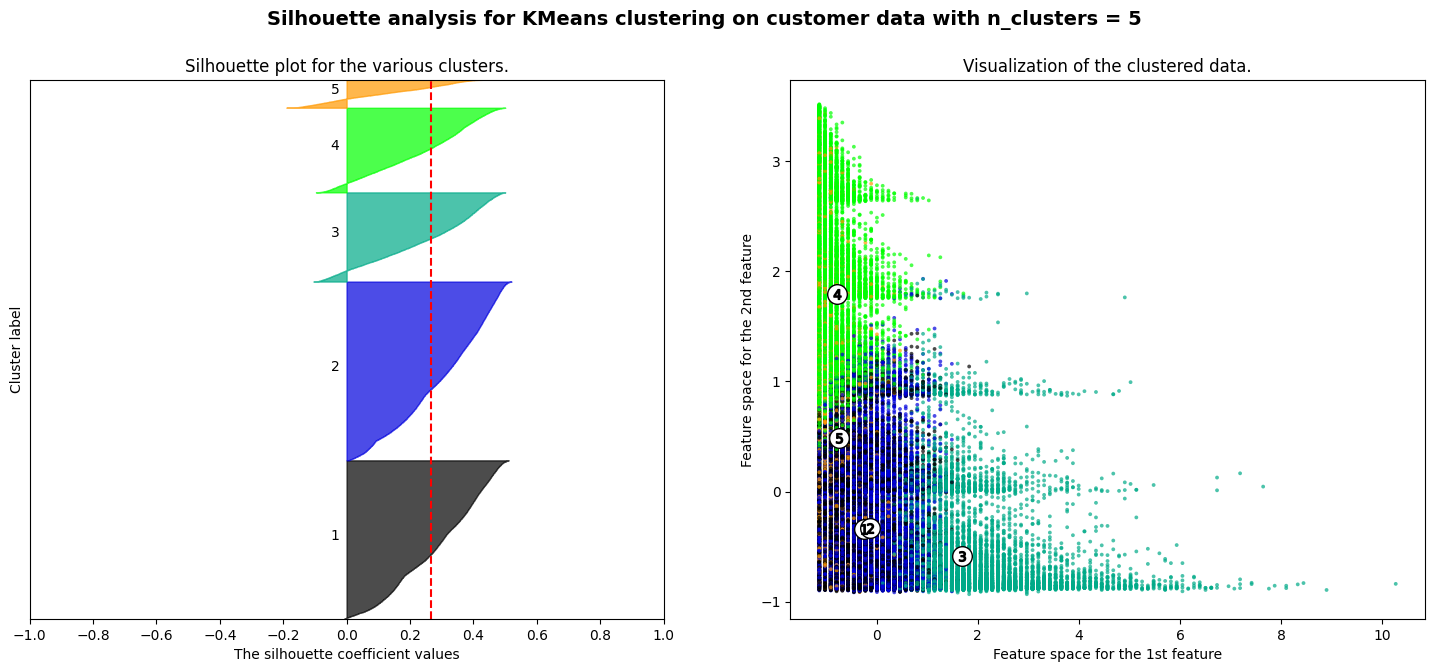

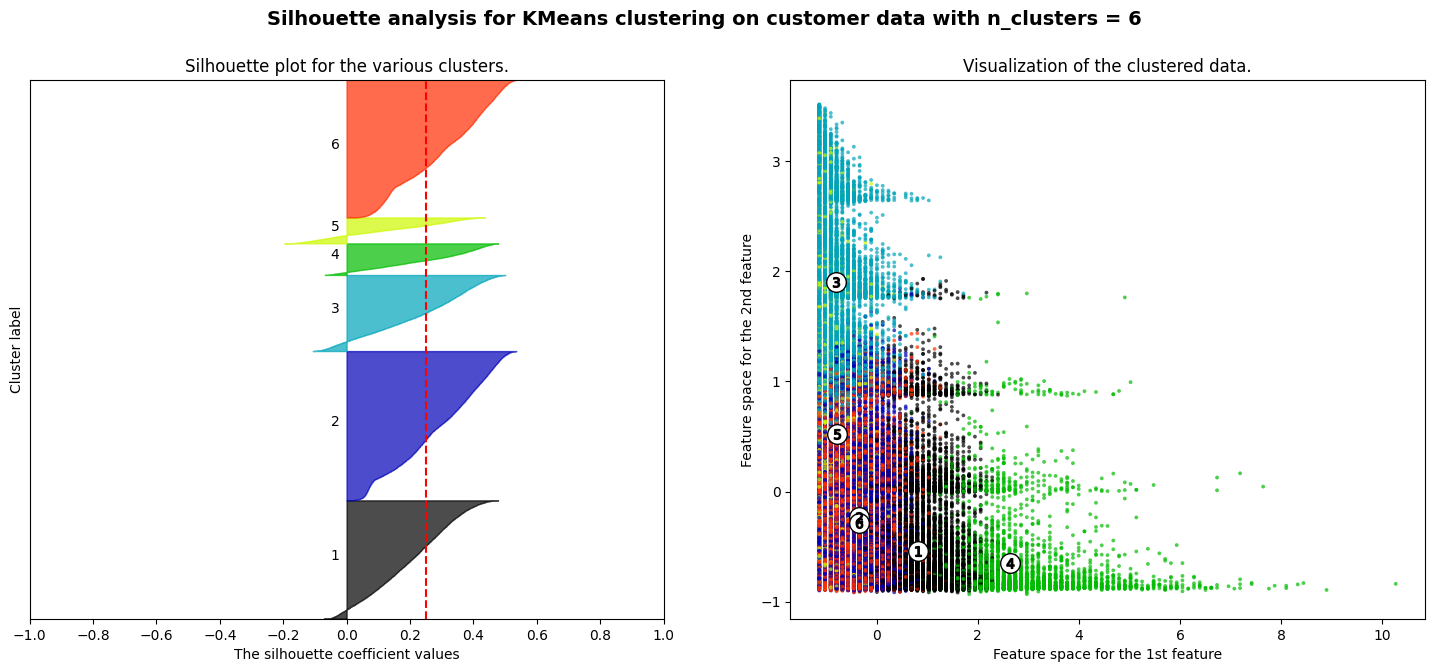

In [ ]:
for n_clusters in n_clusters_range:

    # Create a subplot with 1 row and 2 columns.
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    #Create the silhouette plot.
    ax1.set_xlim([-0.5, 1]) #Set the x axis limits
    ax1.set_ylim([0, len(data_clean) + (n_clusters + 1) * 10]) #Set the y axis limits inc. blank space

    # Initialize the clusterer
    clusterer=KMeans(n_clusters=n_clusters, init='k-means++',random_state=42, n_init = 10)

    #Est. pipline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('clusterer', clusterer)])

    #Fit the pipeline to the data
    pipeline.fit(data_clean[features])

    #Get the cluster labels
    cluster_labels = pipeline.predict(data_clean[features])

    #Get the scaled data
    data_transformed = pipeline.named_steps['preprocessor'].transform(data_clean[features])

    #Get the average silhouette scores
    silhouette_avg = silhouette_score(data_transformed, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is: {silhouette_avg}")

    #Retrieve the silhouette scores, per data point (sample)
    sample_silhouette_values = silhouette_samples(data_transformed, cluster_labels)

    #Identify the min. silhouette score to n_clusters
    print(f"For n_clusters = {n_clusters} clusters, the lowest sample silhouette value is {sample_silhouette_values.min()}")

    # Plot silhouette sample scores
    y_lower = 10 # Used for setting white space gap
    for i in range(n_clusters):
        # Collate the silhouette scores for samples belonging to the given cluster, i
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort() # Ensure lower values are plotted first

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)

        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values, #Draw horizontal line for each silhouette value
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle.
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i+1))

        # Compute the new y_lower for next plot.
        y_lower = y_upper + 10  # 10 for the 0 samples.

    ax1.set_title("Silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values.
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks.
    ax1.set_xticks([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed.
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(data_transformed[:, 0], data_transformed[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Retrieve the cluster centers
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers.
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    #Insert cluster numbers
    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker=f'${i+1}$', alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("Visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on customer data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()

**Reflections on the optimal $k$ in light of the results from the Silhouette method**

The best average silhouette score is 0.267 at $k=5$. However, the silhouette plot shows that this risks misclassifying points - especially in cluster 5, which is also relatively small. The cluster plot also shows clusters heavily overlapping in the center of the feature space.

$K=2$ has the next best average silhouette score - but this may not be granular enough for business purposes.

In light of this, $k=3$ or $k=4$ are worth investigating.

# Hierarchical clustering with dendrogram

In [ ]:
# Create sample of the data to allow for processing
sample_data = data_clean[features].sample(30_000, random_state=42)

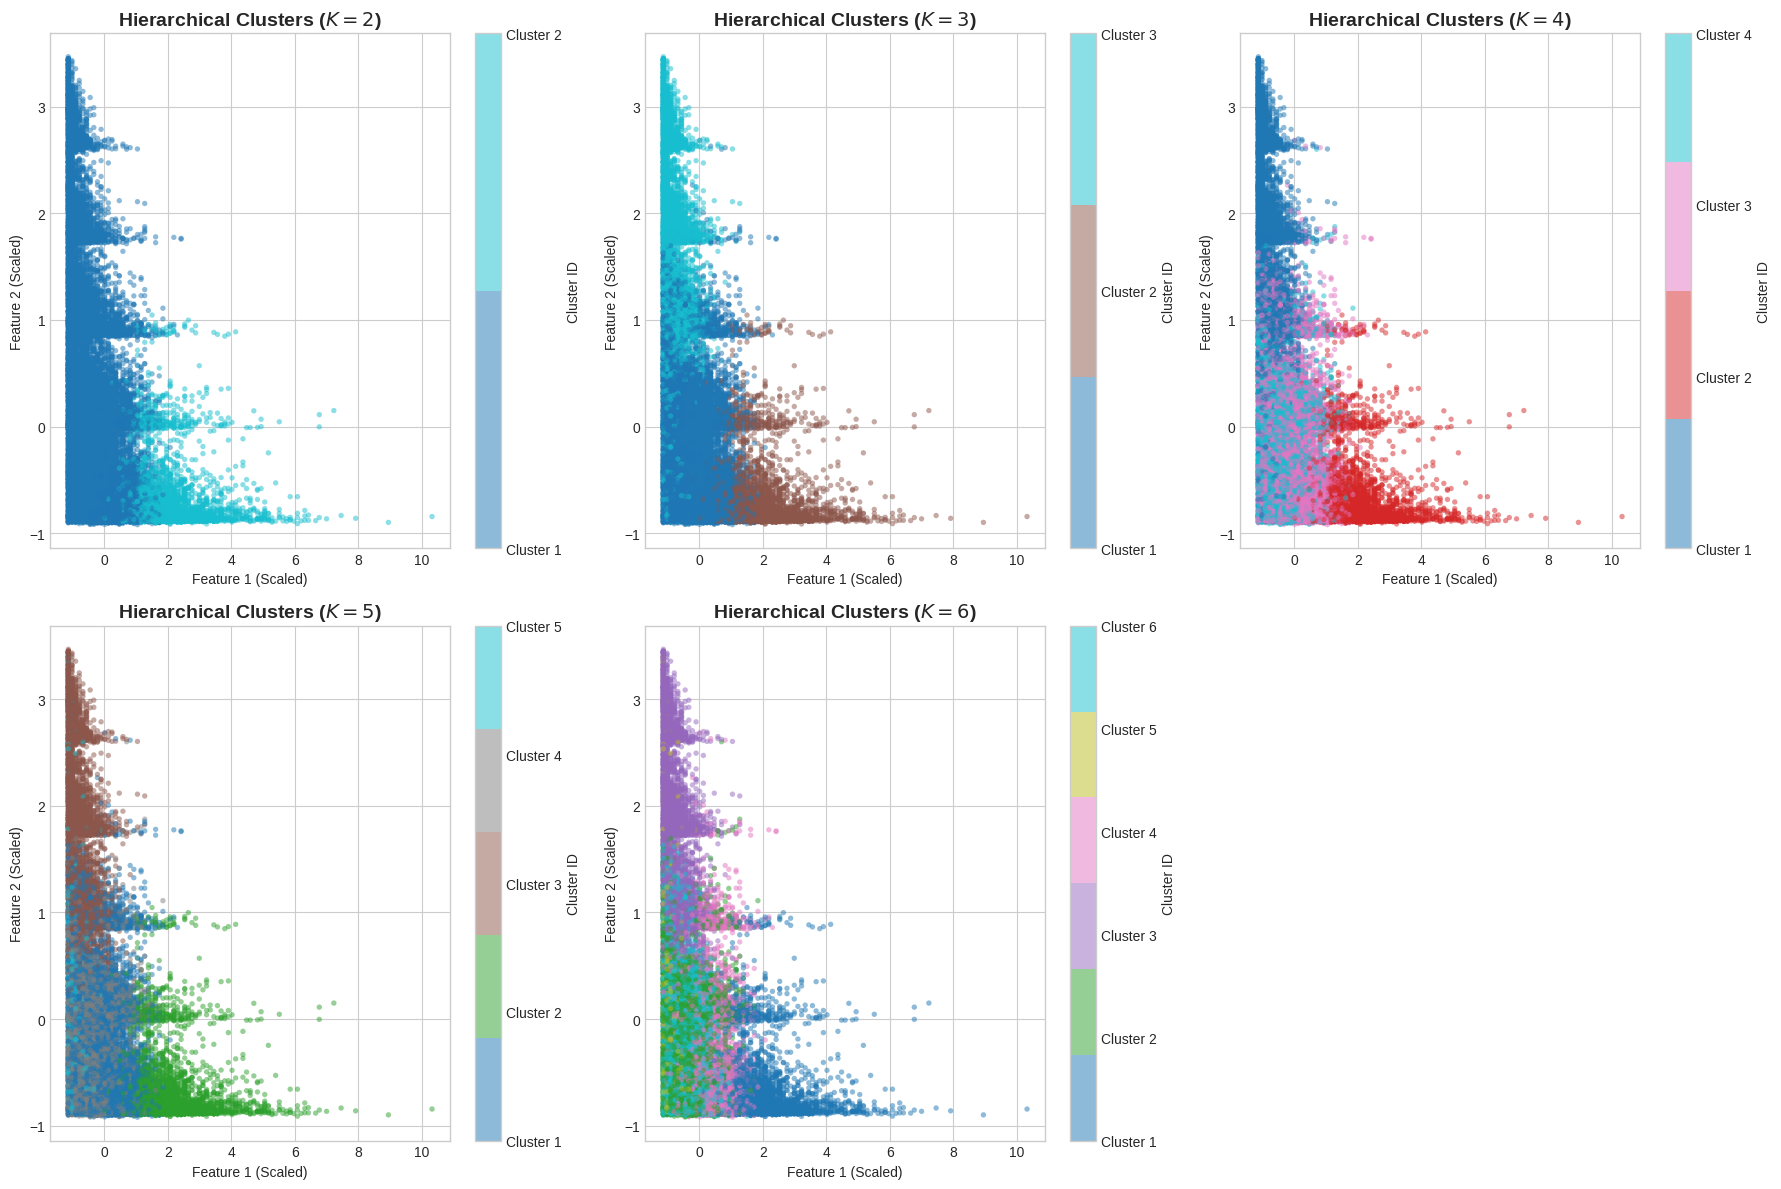

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes_flat = axes.flatten()

for i, n_clusters in enumerate(n_clusters_range):
    ax = axes_flat[i]

    # Initialise the clusterer
    agglo_cluster = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')

    # Est. pipline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('clusterer', agglo_cluster)])

    # Fit and predict to get cluster labels
    cluster_labels = pipeline.fit_predict(sample_data)

    # Labels to display
    display_labels = cluster_labels + 1

    sample_data_transformed = pipeline.named_steps['preprocessor'].transform(sample_data)

    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    custom_cmap = ListedColormap(colors)

    scatter = ax.scatter(sample_data_transformed[:, 0],
                         sample_data_transformed[:, 1],
                         c=display_labels,
                         cmap=custom_cmap,
                         s=15,
                         alpha=0.5,
                         edgecolor='none')

    # Corrected: Set ticks to range(n_clusters) to match the number of labels
    cbar = plt.colorbar(scatter, ax=ax, ticks=range(n_clusters + 1))
    cbar.set_label('Cluster ID', fontsize=10)

    cbar.ax.set_yticklabels([f'Cluster {j}' for j in range(n_clusters + 1)])

    ax.set_title(f'Hierarchical Clusters ($K={n_clusters}$)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature 1 (Scaled)')
    ax.set_ylabel('Feature 2 (Scaled)')

# Hide unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

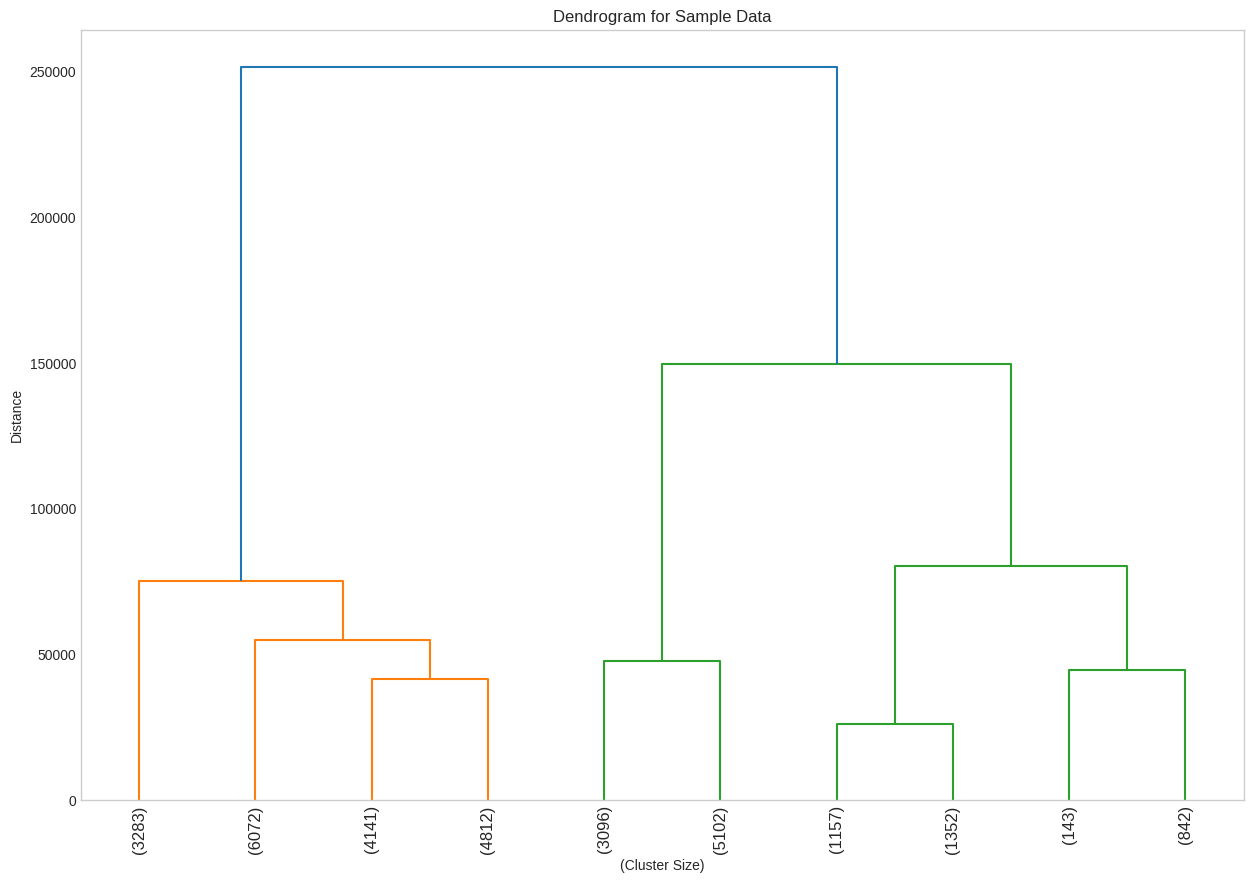

In [ ]:
# Create dendrogram using the ward method

Z = linkage(sample_data, method='ward')
plt.figure(figsize=(15, 10))
dendrogram(Z, truncate_mode='lastp', p=10, leaf_rotation=90., leaf_font_size=12.)

plt.grid(False)
plt.title('Dendrogram for Sample Data')
plt.xlabel('(Cluster Size)')
plt.ylabel('Distance')
plt.show()

# Argument for the choice of $k=3$

The dendrogram suggests that $k=5$ (which had the highest average silhouette score) is "over-clustering" the data and that a lower $k$ is more stable.

It also shows why *k=2* showed a sharp bend in the elbow method - the large vertical distance (the blue line) between the final two branches and the rest of the tree suggests that these are two very distinct clusters.

It is plausible that $k=2$ does not provide enough glanularity for business purposes. If true, the dendogram suggests a natural grouping at $k=3$ - if you draw a horizontal line at c.85,000, you get 3 clusters that are well-separated by significant vertical gaps.

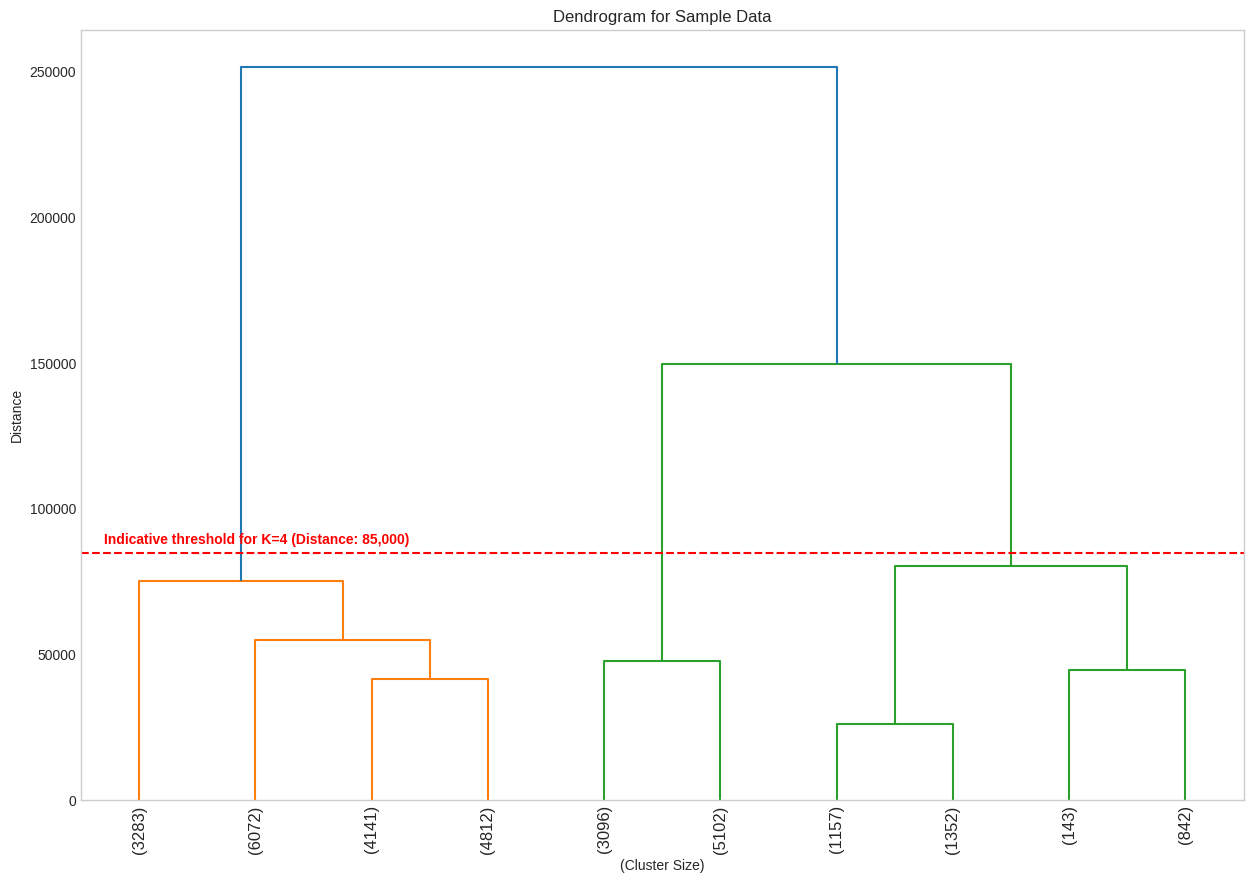

In [ ]:
#Dendogram with k = 3 threshold indicatively marked

plt.figure(figsize=(15, 10))
dendrogram(Z, truncate_mode='lastp', p=10, leaf_rotation=90., leaf_font_size=12.)

plt.grid(False)
plt.title('Dendrogram for Sample Data')
plt.xlabel('(Cluster Size)')
plt.ylabel('Distance')

threshold = 85_000
plt.axhline(y=threshold, color='r', linestyle='--')
plt.text(x=2, y=threshold + 2000, s=f'Indicative threshold for K=4 (Distance: {threshold:,})',
         color='r', fontweight='bold', va='bottom', ha='left')

plt.show()

# Run K means clustering with $k=3$

In [ ]:
k=3

clusterer=KMeans(n_clusters=k, init='k-means++',random_state=42, n_init = 10)

pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('clusterer', clusterer)])

cluster_labels = pipeline.fit_predict(data_clean[features])

data_standardised = pipeline.named_steps['preprocessor'].transform(data_clean[features])

df_data_k3 = pd.DataFrame(data_standardised, columns=features)

In [ ]:
#Display the cluster association for each customer ID in table format.
df_data_k3['Cluster'] = cluster_labels
df_data_k3['Customer ID'] = data_clean['Customer ID']

df_data_k3[['Customer ID', 'Cluster']].sample(10)

,Customer ID,Cluster
10865,14070,0
7329,9447,0
30028,38854,1
16538,21500,1
25551,33111,0
52936,72806,1
66087,91199,0
28047,36303,0
16761,21774,0
16175,21024,0


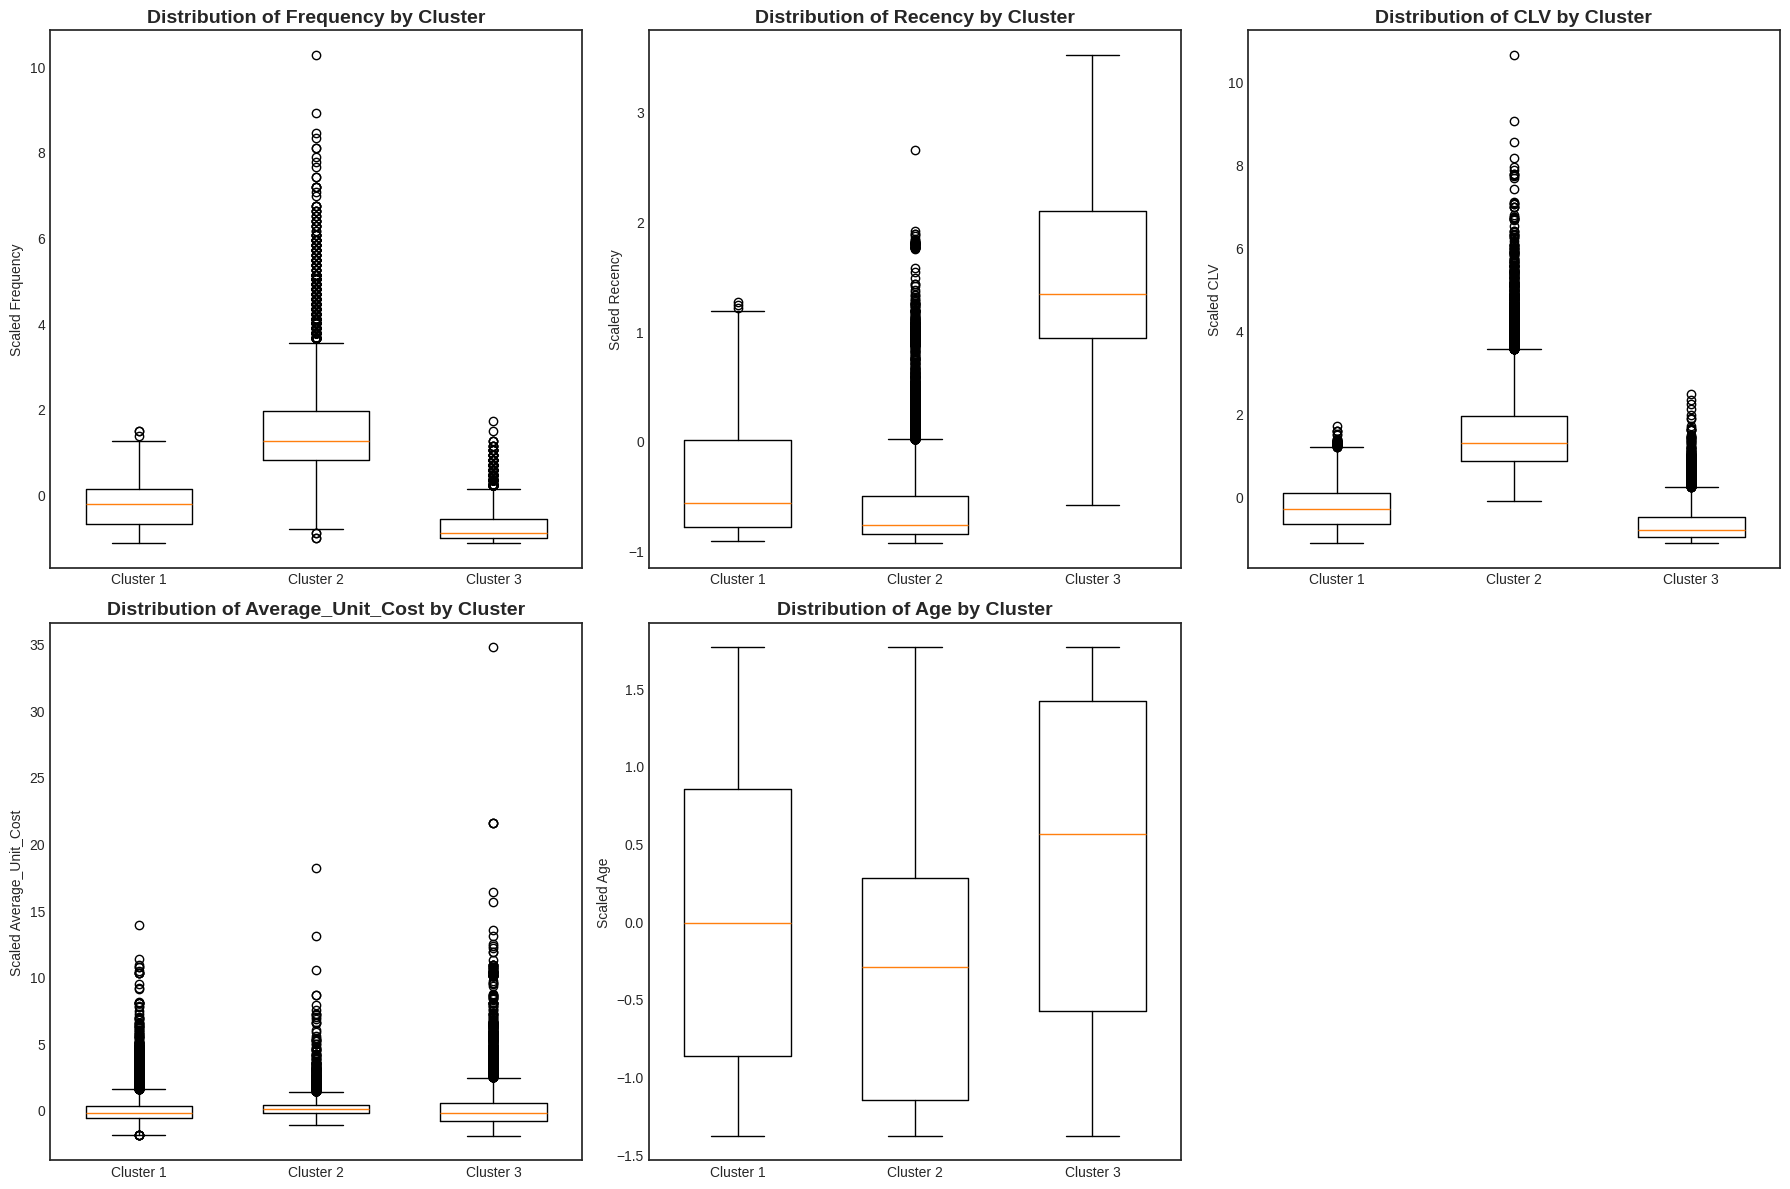

In [ ]:
#Box plot features for each Cluster

k=3

plt.style.use('seaborn-v0_8-white')

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes_flat = axes.flatten()

for i, feature in enumerate(features):
  ax = axes_flat[i]

  boxplot_data = []
  for cluster in range(k):
    cluster_data = df_data_k3.loc[df_data_k3['Cluster'] == cluster]
    boxplot_data.append(cluster_data[feature])

  ax.boxplot(boxplot_data, positions=range(k), widths=0.6)

  ax.set_title(f'Distribution of {feature} by Cluster', fontsize=14, fontweight='bold')
  ax.set_xticks(range(k))
  ax.set_xticklabels([f'Cluster {j+1}' for j in range(k)]) # Label x-ticks for 0-indexed clusters
  ax.set_ylabel(f'Scaled {feature}') # Label y-axis as scaled feature

# Hide unused subplots
for j in range(len(features), len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

# Dimension reduction with PCA and t-SNE

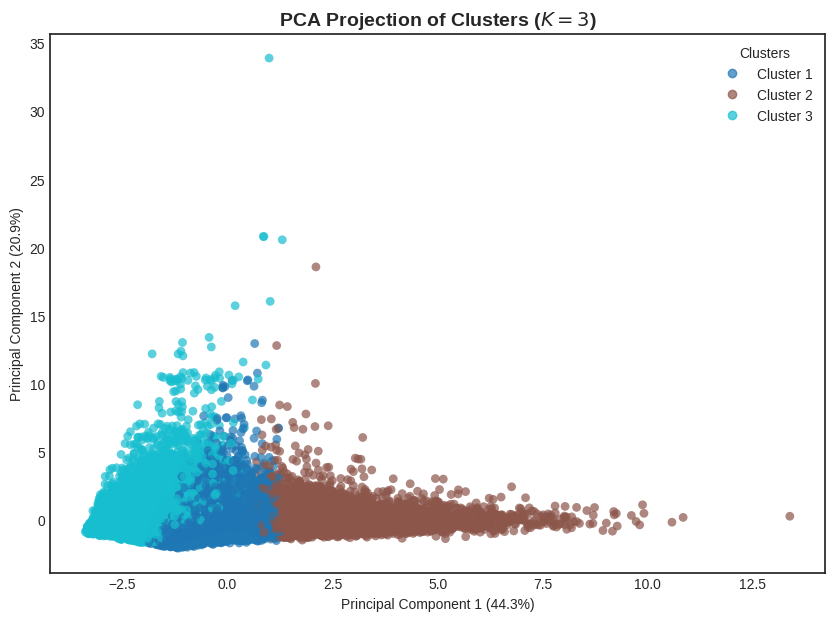

In [ ]:
#Visualise with PCA

n_components = 2
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(data_standardised)

plt.style.use('seaborn-v0_8-white')
plt.figure(figsize=(10, 7))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=cluster_labels,
            cmap='tab10',
            s=40,
            alpha=0.7,
            edgecolor='none')

handles, _ = scatter.legend_elements()
plt.legend(handles, [f'Cluster {i+1}' for i in range(len(handles))],
           title="Clusters", loc="best")

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Projection of Clusters ($K=3$)', fontsize=14, fontweight='bold')
plt.grid(False)

plt.show()




In [ ]:
n_samples = 30_000

rng = np.random.default_rng(42)
random_indices = rng.choice(data_standardised.shape[0], n_samples, replace=False)
sample_data_tsne = data_standardised[random_indices]

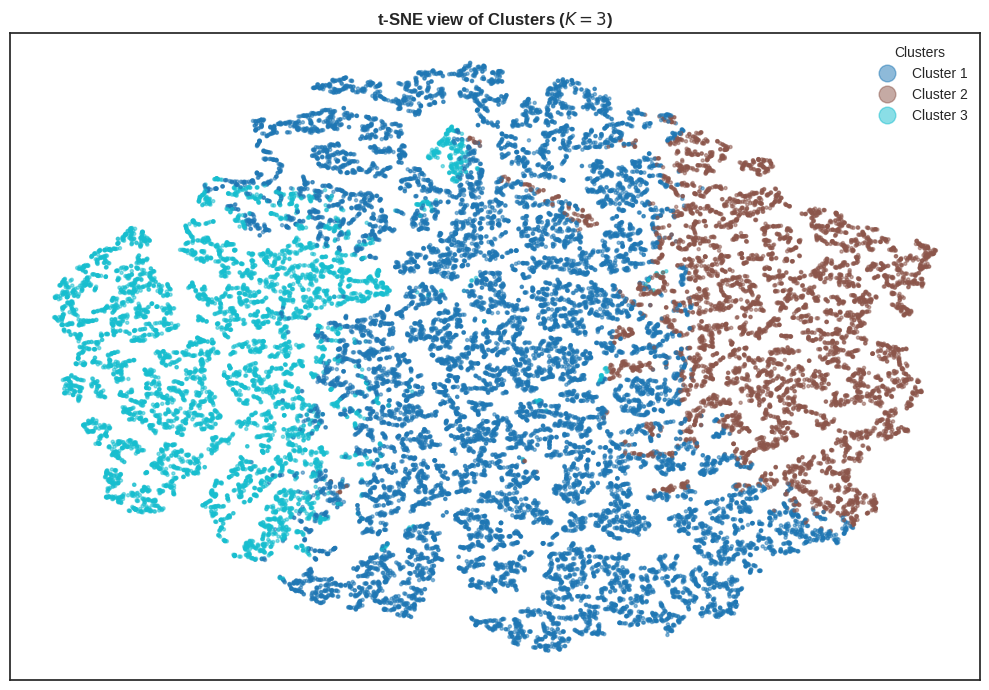

In [ ]:
#Visualise with t-SNE

tsne = TSNE(n_components=2,
            perplexity=20,
            random_state=42,
            init='pca',
            learning_rate='auto'
            )

tsne_results = tsne.fit_transform(sample_data_tsne)
cluster_labels = cluster_labels[random_indices]

plt.figure(figsize=(10, 7))
ax = plt.gca()

scatter = ax.scatter(tsne_results[:, 0],
                      tsne_results[:, 1],
                      c=cluster_labels,
                      cmap='tab10',
                      alpha=0.5,
                      s=5)

handles, _ = scatter.legend_elements()
ax.legend(handles, [f'Cluster {j+1}' for j in range(len(handles))],
          title="Clusters", loc='best', markerscale=2)

ax.set_title('t-SNE view of Clusters ($K=3$)', fontsize=12, fontweight='bold')
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

# Thoughts and Observations on the reduction techniques
PCA is more effective at showing the outliers in the data, and the influence of the Principal Components - for example, you can see that Cluster Two varies most on PSA Principal Component One, Cluster Three on Principal Component Two.

On the other hand, t-SNE is more effective at showing that $k=3$ is producing distinct customer segments, with their own space.

Both visualisations show where there is 'blending' with Cluster One.

# Reflect
Empirical evidence from both centroid and hierarchical models supports a three-cluster segmentation.

Box plots reveal that Recency and Age are the primary differentiators for Cluster 3. Notably, Average Unit Cost appeared to have minimal impact on the final cluster formations, suggesting it is not a primary driver of customer behavior in this dataset.

Visualisations help convey the customer segmentation, and provide a usful artifact to engage business expertise.

### Reference:
SAS, 2024. CUSTOMERS_CLEAN [Data set]. SAS. Last revised on 15 December 2021. [Accessed 20 February 2024].